In [1]:
import cv2
import mediapipe as mp
import csv
import os
import numpy as np
import joblib

In [2]:
# Setup Mediapipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2)

In [3]:
# Path to the main folder (the one containing A, B, C folders)
base_path = './data'

# Open CSV file to save landmarks
with open('hand_landmarks_dataset.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    # Header (21 landmarks per hand x,y,z + Label)
    header = []
    for hand in ['LH', 'RH']:
        for i in range(21):
            header.extend([f'{hand}_x{i}', f'{hand}_y{i}', f'{hand}_z{i}'])
    header.append('Label')
    writer.writerow(header)

    # Loop through each subfolder (A, B, C)
    for sign in ['A', 'B', 'C','hand']:
        folder_path = os.path.join(base_path, sign)

        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        # Read only image files (jpg, png, jpeg)
        for filename in os.listdir(folder_path):
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue  # Skip non-image files (or folders)

            image_path = os.path.join(folder_path, filename)
            image = cv2.imread(image_path)

            if image is None:
                print(f"Could not read image {image_path}, skipping.")
                continue

            # Process image using Mediapipe
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results = hands.process(rgb_image)

            # Collect landmarks (2 hands max)
            landmarks = []

            if results.multi_hand_landmarks:
                for hand_index in range(2):
                    if hand_index < len(results.multi_hand_landmarks):
                        hand_landmarks = results.multi_hand_landmarks[hand_index]
                        for landmark in hand_landmarks.landmark:
                            landmarks.extend([landmark.x, landmark.y, landmark.z])
                    else:
                        landmarks.extend([0.0, 0.0, 0.0] * 21)  # Pad missing hand
            else:
                # No hands detected at all 
                landmarks.extend([0.0, 0.0, 0.0] * 21 * 2)

            # Append the label (A, B, C)
            landmarks.append(sign)

            # Write to CSV
            writer.writerow(landmarks)

print("Landmark extraction complete! Saved to 'hand_landmarks_dataset.csv'")

Landmark extraction complete! Saved to 'hand_landmarks_dataset.csv'


Epoch 1/6


C:\Users\charl\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4978 - loss: 1.1919 - val_accuracy: 0.8889 - val_loss: 0.3692
Epoch 2/6
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8980 - loss: 0.3427 - val_accuracy: 0.9722 - val_loss: 0.1497
Epoch 3/6
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9520 - loss: 0.2031 - val_accuracy: 0.9722 - val_loss: 0.1514
Epoch 4/6
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9437 - loss: 0.2146 - val_accuracy: 0.9722 - val_loss: 0.0994
Epoch 5/6
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9328 - loss: 0.1705 - val_accuracy: 0.9722 - val_loss: 0.1503
Epoch 6/6
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9577 - loss: 0.1500 - val_accuracy: 0.9722 - val_loss: 0.0687
2/2 - 0s - 18ms/step - accuracy: 0.9722 - loss: 0.0687
Test Accuracy: 97.22222%


Overall accuracy (computed from CSV): 97.22%
Predictions (with accuracy) saved to 'predicted_signs.csv'
Neural network model trained and saved as 'sign_language_nn_model.h5'


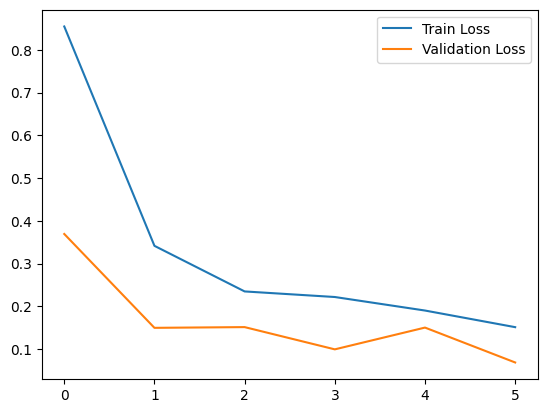

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import joblib


# Load dataset
df = pd.read_csv('hand_landmarks_dataset.csv')
# Features (landmarks) and labels (A, B, C)
X = df.iloc[:, :-1].values  # All columns except 'Label'
y = df['Label'].values  # Last column (A, B, C)
# Encode labels to numbers (A = 0, B = 1, C = 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
# Normalize features (scaling for stability)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Save scaler for real-time prediction later
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
# Build neural network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(4, activation='softmax')  # 4 classes: A, B, C, hand
])

# Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train
history = model.fit(X_train, y_train, epochs=6, batch_size=16, validation_data=(X_test, y_test))


# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {test_acc*100:.5f}%")


# Save predictions to CSV
#Predict on the test set
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Convert numeric labels back to strings
y_true_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred)


# Build the DataFrame
results_df = pd.DataFrame({
    "True Label":      y_true_labels,
    "Predicted Label": y_pred_labels
})
# Flag correct / wrong
results_df["Correct"] = (results_df["True Label"]== results_df["Predicted Label"]).astype(int)
# Overall accuracy (Same as test accuracy)

overall_acc = results_df["Correct"].mean() * 100
print(f"Overall accuracy (computed from CSV): {overall_acc:.2f}%")

summary_row = pd.DataFrame(
    [{"True Label": "", "Predicted Label": "",
      "Correct": f"Accuracy: {overall_acc:.5f}%"}]
)
results_df = pd.concat([results_df, summary_row], ignore_index=True)

# Save to CSV

results_df.to_csv("predicted_signs.csv", index=False)
print("Predictions (with accuracy) saved to 'predicted_signs.csv'")
# Save the trained model
model.save('sign_language_nn_model.h5')

print("Neural network model trained and saved as 'sign_language_nn_model.h5'")

# Plotting training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [12]:
import cv2
import mediapipe as mp
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import csv
import datetime
import os

# CSV setup
csv_file_path = 'realtime_predictions.csv'
file_exists = os.path.isfile(csv_file_path)

csv_file = open(csv_file_path, mode='w', newline='')
csv_writer = csv.writer(csv_file)
csv_file.flush() 

# Write header only once
if not file_exists:
    csv_writer.writerow(["Timestamp", "Predicted Label", "Confidence"])


# Load model and preprocessing helpers
model          = load_model('sign_language_nn_model.h5')
scaler         = joblib.load('scaler.pkl')
label_encoder  = joblib.load('label_encoder.pkl')

# Mediapipe Hands
mp_hands        = mp.solutions.hands
mp_drawing      = mp.solutions.drawing_utils
mp_draw_styles  = mp.solutions.drawing_styles

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Webcam
cap = cv2.VideoCapture(1)# If the webcam doesnt detect, try changing the values to 0 or 1 
#Press Q to Quit Program

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        continue

    frame_flipped = cv2.flip(frame, 1)
    rgb_frame     = cv2.cvtColor(frame_flipped, cv2.COLOR_BGR2RGB)
    results       = hands.process(rgb_frame)

    landmarks = []

    if results.multi_hand_landmarks:
        # Draw and collect 2 hands
        for idx in range(2):
            if idx < len(results.multi_hand_landmarks):
                hand_lm = results.multi_hand_landmarks[idx]
                mp_drawing.draw_landmarks(
                    frame_flipped,
                    hand_lm,
                    mp_hands.HAND_CONNECTIONS,
                    mp_draw_styles.get_default_hand_landmarks_style(),
                    mp_draw_styles.get_default_hand_connections_style()
                )
                for lm in hand_lm.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])
            else:
                # Hand missing → pad zeros (21 landmarks × 3 coords)
                landmarks.extend([0.0, 0.0, 0.0] * 21)
    else:
        # No hands → pad for both hands
        landmarks.extend([0.0, 0.0, 0.0] * 21 * 2)

    label   = "Unknown"
    conf    = 0.0

    if len(landmarks) == 126 and any(landmarks):   
        sample     = scaler.transform([landmarks])
        probs      = model.predict(sample, verbose=0)
        conf       = np.max(probs)
        pred_idx   = np.argmax(probs)
        label      = label_encoder.inverse_transform([pred_idx])[0]

            

        # low confidence is treated as unkown
        if conf < 0.50:
            label = "Unknown"
            
        csv_writer.writerow([datetime.datetime.now(), label, conf])

    cv2.putText(
        frame_flipped,
        f'Sign: {label} ({conf:.2f})',
        (50, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imshow('Sign Language Detection', frame_flipped)

    #Press Q to Quit Program


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
csv_file.close()